# Stroke Risk Prediction — Modeling (V3)

---

## Pipeline Modeling

| Étape | Section | Ce qu'on fait |
|---|---|---|
| Imports + Chargement | 1 | `config.py` + librairies + `df_features.csv` + `load_features()` |
| Features Sélectionnées | 2 | Chargées depuis `df_features.csv` — feature selection déjà faite en V2 |
| Split stratifié | 3 | 80/20 sur `SELECTED_FEATURES` — `stratify=y` |
| ImbPipeline + SMOTE | 4 | `SMOTE` → `StandardScaler` → `Model` sur `X_train` uniquement |
| RandomizedSearchCV | 5 | Optimisation `scoring='recall'` sur 3 modèles |
| GridSearchCV | 5b | Comparaison avec GridSearchCV — mêmes hyperparamètres |
| Évaluation | 6 | Accuracy, Recall, F1, AUC-ROC — meilleur modèle retenu |
| Visualisation | 7 | Barplot métriques + Confusion matrices + Courbes ROC |
| Analyse des erreurs | 8 | Faux négatifs — quels AVC sont manqués ? |
| Permutation Importance | 9 | Variables les plus importantes pour la prédiction |
| Conclusion | 10 | Performance + applicabilité réelle |
| Sauvegarde | 11 | `pipeline.pkl` + `features.pkl` |

---

**Prérequis** : `2_Preprocessing_v2.ipynb` exécuté — génère `df_features.csv`  
**Sortie** : `pipeline.pkl` + `features.pkl`  

## 1. Imports, Chargement & Variables

In [3]:
!pip install xgboost       -q

In [4]:
import sys
import os

# Vider le cache — évite que Python utilise config.py d'un autre notebook
sys.path = [p for p in sys.path if 'src' not in p]
if 'config' in sys.modules:
    del sys.modules['config']

# Ajouter le src de V3
sys.path.insert(0, os.path.abspath('./src'))

import importlib
import config
importlib.reload(config)
from config import TARGET, RANDOM_STATE, CLEAN_PATH, check_data_quality, load_features, FEATURES_PATH

import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.inspection import permutation_importance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

# Chargement variables et dataset
TARGET, CATEGORICAL_VARS, NUMERICAL_VARS, ALL_FEATURES = load_features()

df = pd.read_csv(FEATURES_PATH)
df = df.drop_duplicates().reset_index(drop=True)
is_clean = check_data_quality(df)
if not is_clean:
    raise ValueError('Dataset non propre — relancer 2_Preprocessing_v2.ipynb.')

print(f'Dataset chargé : {df.shape[0]} lignes x {df.shape[1]} colonnes')

features.json chargé :
  target           : stroke
  categorical_vars : 15 variables
  numerical_vars   : 20 variables
  Data Quality Report

Valeurs manquantes : 0
  Aucune valeur manquante.

Doublons : 0
  Aucun doublon.

Shape : 4603 lignes x 18 colonnes
Dataset chargé : 4603 lignes x 18 colonnes


## 2. Features Sélectionnées

`df_features.csv` contient déjà les features issues de la feature selection V2.  
On définit ici `SELECTED_FEATURES` et `NUM_SELECTED` directement depuis le dataset chargé.

In [5]:
# Features sélectionnées — issues de Modeling V2 (df_features.csv)
SELECTED_FEATURES = [col for col in df.columns if col != TARGET]
NUM_SELECTED      = [col for col in SELECTED_FEATURES if col in NUMERICAL_VARS]

print(f'Features sélectionnées : {len(SELECTED_FEATURES)}')
print(f'  Numériques           : {len(NUM_SELECTED)}')
print(f'  Catégorielles        : {len(SELECTED_FEATURES) - len(NUM_SELECTED)}')
print(f'  {SELECTED_FEATURES}')

Features sélectionnées : 17
  Numériques           : 7
  Catégorielles        : 10
  ['age', 'Coronary Heart Disease', 'General health condition', 'protein', 'high cholesterol', 'Total polyunsaturated fatty acids', 'depression', 'hypertension', 'diabetes', 'Low-density lipoprotein', 'smoke', 'Health Insurance', 'Dietary fiber', 'Total saturated fatty acids', 'Carbohydrate', 'Minutes sedentary activity', 'Race']


## 3. Split stratifié — 80/20

Identique à V2.  
**SMOTE sera appliqué uniquement sur `X_train`** à l'intérieur du pipeline — jamais sur `X_test`.

In [6]:
X = df[SELECTED_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('=== Train / Test Split ===')
print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')
vc_train = y_train.value_counts()
vc_test  = y_test.value_counts()
print(f'y_train — No stroke: {vc_train[0]} ({vc_train[0]/len(y_train)*100:.1f}%)  Stroke: {vc_train[1]} ({vc_train[1]/len(y_train)*100:.1f}%)')
print(f'y_test  — No stroke: {vc_test[0]}  ({vc_test[0]/len(y_test)*100:.1f}%)  Stroke: {vc_test[1]}  ({vc_test[1]/len(y_test)*100:.1f}%)')

=== Train / Test Split ===
X_train : (3682, 17)  |  X_test : (921, 17)
y_train — No stroke: 3392 (92.1%)  Stroke: 290 (7.9%)
y_test  — No stroke: 849  (92.2%)  Stroke: 72  (7.8%)


## 4. ImbPipeline + SMOTE

`ImbPipeline` de `imbalanced-learn` supporte SMOTE dans le pipeline.  

**Ordre :**
1. `SMOTE` — rééquilibrage sur `X_train` uniquement
2. `StandardScaler` sur `NUM_SELECTED`
3. `Model` — LR / RF / XGBoost

Pas de `class_weight='balanced'` — doublon avec SMOTE.

In [7]:
def make_imb_pipeline(model):
    preprocessor = ColumnTransformer(
        transformers=[('num', StandardScaler(), NUM_SELECTED)],
        remainder='passthrough'
    )
    return ImbPipeline(steps=[
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('preprocessor', preprocessor),
        ('model', model)
    ])


pipelines = {
    'Logistic Regression': make_imb_pipeline(
        LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    ),
    'Random Forest': make_imb_pipeline(
        RandomForestClassifier(random_state=RANDOM_STATE)
    ),
    'XGBoost': make_imb_pipeline(
        XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0)
    )
}


print(f'{len(pipelines)} pipelines — SMOTE + StandardScaler + modèle')
for name in pipelines:
    print(f'  - {name}')

3 pipelines — SMOTE + StandardScaler + modèle
  - Logistic Regression
  - Random Forest
  - XGBoost


## 5. RandomizedSearchCV
il explore aléatoirement `n_iter` combinaisons au lieu de toutes les tester.

In [8]:
# Espaces de recherche par modèle
param_grids = {
    'Logistic Regression': {
        'model__C'      : [0.01, 0.1, 1, 10, 100],
        'model__solver' : ['lbfgs', 'liblinear']
    },
    'Random Forest': {
        'model__n_estimators'     : [100, 200, 300],
        'model__max_depth'        : [None, 5, 10, 20],
        'model__min_samples_split': [2, 5, 10]
    },
    'XGBoost': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth'   : [3, 5, 7],
        'model__learning_rate': [0.01, 0.1, 0.2],
        'model__subsample'   : [0.7, 0.8, 1.0]
    }
}

best_models   = {}
results       = []

for name, pipeline in pipelines.items():
    print(f'\nOptimisation : {name} ...')

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[name],
        n_iter=50,
        scoring = 'recall',
        cv = 5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

    search.fit(X_train,y_train)
    
    best_models[name] = search.best_estimator_
    print(f'  Meilleurs paramètres : {search.best_params_}')
    print(f'  Recall CV            : {search.best_score_:.4f}')
    


Optimisation : Logistic Regression ...
  Meilleurs paramètres : {'model__solver': 'liblinear', 'model__C': 0.01}
  Recall CV            : 0.4966

Optimisation : Random Forest ...
  Meilleurs paramètres : {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__max_depth': 5}
  Recall CV            : 0.4241

Optimisation : XGBoost ...
  Meilleurs paramètres : {'model__subsample': 0.7, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.01}
  Recall CV            : 0.4862


## 6.GridSearchCV

In [9]:
best_models_grid = {}

for name, pipeline in pipelines.items():
    print(f'\nGridSearchCV : {name} ...')

    grid_search  = GridSearchCV(
        estimator=pipeline,
        param_grid = param_grids[name],
        scoring    = 'recall',
        cv         = 5,
        n_jobs     = -1
    )

    grid_search.fit(X_train, y_train)

    best_models_grid[name] = grid_search.best_estimator_
    print(f'  Meilleurs paramètres : {grid_search.best_params_}')
    print(f'  Recall CV            : {grid_search.best_score_:.4f}')


GridSearchCV : Logistic Regression ...
  Meilleurs paramètres : {'model__C': 0.01, 'model__solver': 'liblinear'}
  Recall CV            : 0.4966

GridSearchCV : Random Forest ...
  Meilleurs paramètres : {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}
  Recall CV            : 0.4241

GridSearchCV : XGBoost ...
  Meilleurs paramètres : {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}
  Recall CV            : 0.5103


In [10]:
# Modèles retenus — GridSearchCV (meilleur ou égal sur tous les modèles)
best_models_final = best_models_grid
print('Modèles retenus : GridSearchCV')

Modèles retenus : GridSearchCV


## 7. Évaluation sur X_test

In [11]:
results = [] 
colors = ['#4C9BE8', '#6DBF8E', '#E8614C']

for name, model in best_models_grid.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_test, y_pred, zero_division=0), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_prob), 4),
    })

results_df = pd.DataFrame(results).set_index('Model')
print('=== Résultats V3 — GridSearchCV ===')
print(results_df.to_string())

=== Résultats V3 — GridSearchCV ===
                     Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                            
Logistic Regression    0.6015     0.0774  0.3750  0.1283   0.5300
Random Forest          0.5635     0.0833  0.4583  0.1410   0.5325
XGBoost                0.4875     0.0816  0.5417  0.1418   0.5355



=== Logistic Regression ===
 Seuil  Accuracy  Recall     F1
  0.10    0.0934  1.0000 0.1471
  0.15    0.1129  0.9861 0.1481
  0.20    0.1498  0.9306 0.1461
  0.25    0.2161  0.9028 0.1526
  0.30    0.2671  0.7917 0.1445
  0.35    0.3366  0.7361 0.1478
  0.40    0.4419  0.6806 0.1601
  0.45    0.5201  0.5139 0.1434
  0.50    0.6015  0.3750 0.1283
  0.55    0.6851  0.2917 0.1265
  0.60    0.7600  0.1806 0.1053
  0.65    0.8350  0.1528 0.1264
  0.70    0.8838  0.0972 0.1157
  0.75    0.9110  0.0417 0.0682
  0.80    0.9186  0.0139 0.0260
  0.85    0.9207  0.0000 0.0000
Meilleur seuil (F1 max) : 0.4

=== Random Forest ===
 Seuil  Accuracy  Recall     F1
  0.10    0.0923  0.9861 0.1452
  0.15    0.1227  0.9583 0.1459
  0.20    0.1824  0.9306 0.1511
  0.25    0.2454  0.8611 0.1514
  0.30    0.2975  0.8056 0.1520
  0.35    0.3377  0.7222 0.1457
  0.40    0.3779  0.6528 0.1409
  0.45    0.4484  0.5556 0.1361
  0.50    0.5635  0.4583 0.1410
  0.55    0.6916  0.3194 0.1394
  0.60    0.7991  0.23

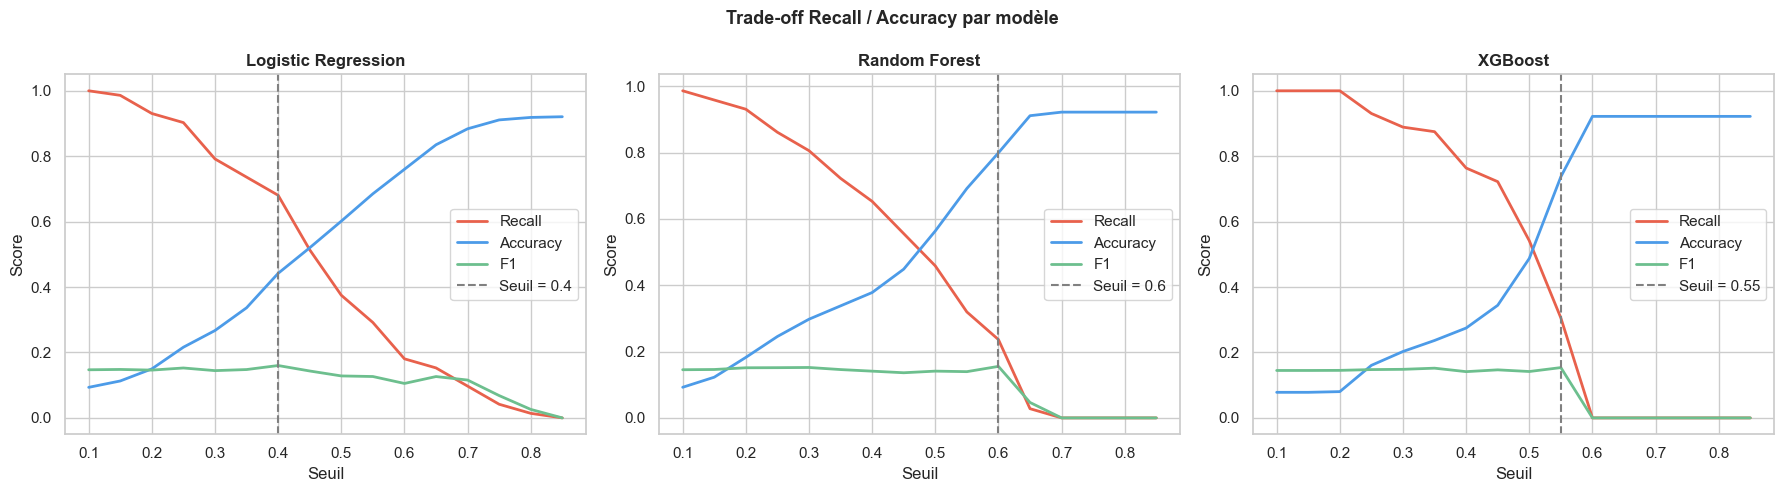

In [12]:
# ── Analyse des seuils — tous les modèles ──────────────────
thresholds = np.arange(0.1, 0.9, 0.05)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

best_thresholds = {}

for i, (name, model) in enumerate(best_models_final.items()):
    y_prob = model.predict_proba(X_test)[:, 1]
    results_thresh = []

    for thresh in thresholds:
        y_pred_thresh = (y_prob >= thresh).astype(int)
        results_thresh.append({
            'Seuil'   : round(thresh, 2),
            'Accuracy': round(accuracy_score(y_test, y_pred_thresh), 4),
            'Recall'  : round(recall_score(y_test, y_pred_thresh, zero_division=0), 4),
            'F1'      : round(f1_score(y_test, y_pred_thresh, zero_division=0), 4),
        })

    thresh_df = pd.DataFrame(results_thresh)

    # Meilleur seuil selon F1
    best_thresh = thresh_df.loc[thresh_df['F1'].idxmax(), 'Seuil']
    best_thresholds[name] = best_thresh

    print(f'\n=== {name} ===')
    print(thresh_df.to_string(index=False))
    print(f'Meilleur seuil (F1 max) : {best_thresh}')

    # Visualisation
    axes[i].plot(thresh_df['Seuil'], thresh_df['Recall'],   label='Recall',   color='#E8614C', linewidth=2)
    axes[i].plot(thresh_df['Seuil'], thresh_df['Accuracy'], label='Accuracy', color='#4C9BE8', linewidth=2)
    axes[i].plot(thresh_df['Seuil'], thresh_df['F1'],       label='F1',       color='#6DBF8E', linewidth=2)
    axes[i].axvline(x=best_thresh, color='gray', linestyle='--', label=f'Seuil = {best_thresh}')
    axes[i].set_title(f'{name}', fontweight='bold')
    axes[i].set_xlabel('Seuil')
    axes[i].set_ylabel('Score')
    axes[i].legend()

plt.suptitle('Trade-off Recall / Accuracy par modèle', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
results_final = []

for name, model in best_models_final.items():
    thresh = best_thresholds[name]  # ← seuil optimal par modèle
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred_thresh = (y_prob >= thresh).astype(int)

    results_final.append({
        'Model'    : name,
        'Seuil'    : thresh,
        'Accuracy' : round(accuracy_score(y_test, y_pred_thresh), 4),
        'Precision': round(precision_score(y_test, y_pred_thresh, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred_thresh, zero_division=0), 4),
        'F1'       : round(f1_score(y_test, y_pred_thresh, zero_division=0), 4),
        'AUC-ROC'  : round(roc_auc_score(y_test, y_prob), 4),
    })

results_final_df = pd.DataFrame(results_final).set_index('Model')
print('=== Résultats finaux — Seuil optimal par modèle ===')
print(results_final_df.to_string())

=== Résultats finaux — Seuil optimal par modèle ===
                     Seuil  Accuracy  Precision  Recall      F1  AUC-ROC
Model                                                                   
Logistic Regression   0.40    0.4419     0.0907  0.6806  0.1601   0.5300
Random Forest         0.60    0.7991     0.1156  0.2361  0.1553   0.5325
XGBoost               0.55    0.7372     0.1028  0.3056  0.1538   0.5355


## 8. Visualisation des Résultats

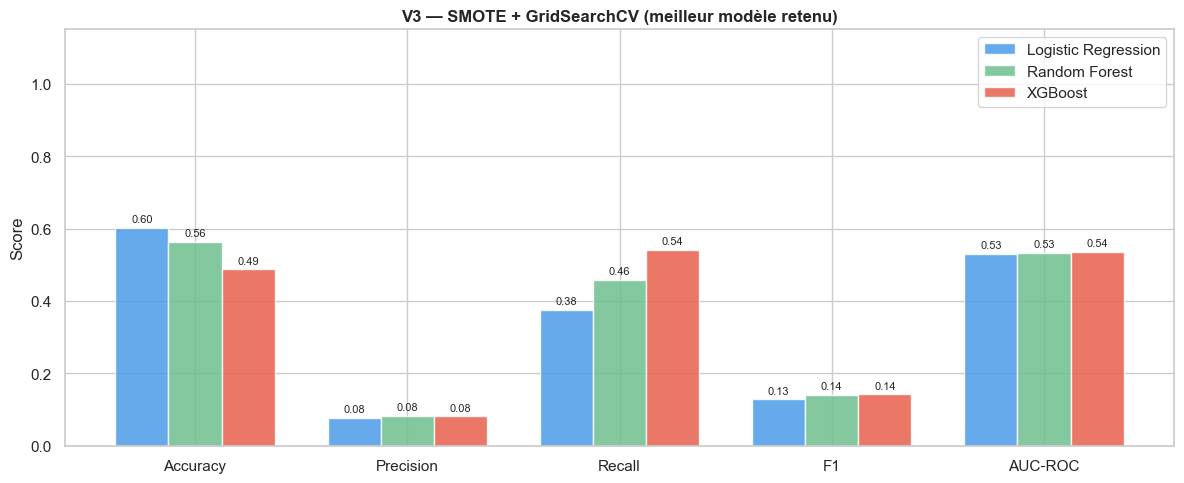

In [14]:
# Barplot comparatif
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC']

fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(metrics_cols))
width = 0.25

for i, (name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics_cols]
    bars = ax.bar(x + i * width, vals, width, label=name,
                  color=colors[i], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_cols)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score')
ax.set_title('V3 — SMOTE + GridSearchCV (meilleur modèle retenu)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

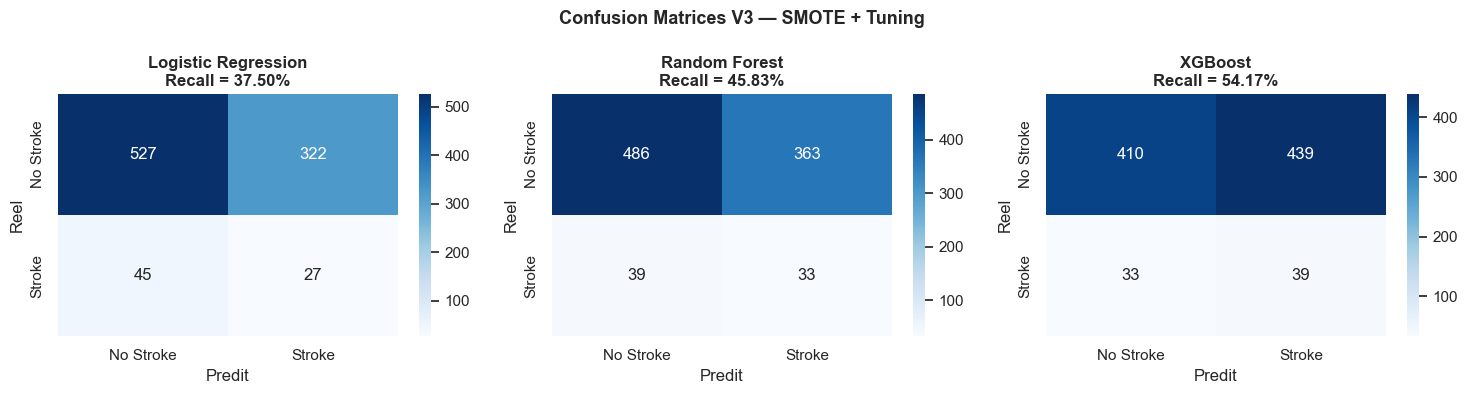

In [15]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (name, model) in enumerate(best_models_final.items()):
    y_pred     = model.predict(X_test)
    cm         = confusion_matrix(y_test, y_pred)
    recall_val = recall_score(y_test, y_pred, zero_division=0)

    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['No Stroke', 'Stroke'],
        yticklabels=['No Stroke', 'Stroke'],
        ax=axes[i]
    )
    axes[i].set_title(f'{name}\nRecall = {recall_val:.2%}', fontweight='bold')
    axes[i].set_ylabel('Reel')
    axes[i].set_xlabel('Predit')

plt.suptitle('Confusion Matrices V3 — SMOTE + Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Analyse des Erreurs — Faux Négatifs

Dans un contexte médical, les **faux négatifs** sont les erreurs les plus graves —  un patient avec AVC prédit comme sain.

On analyse le profil des patients mal classifiés par le meilleur modèle.

In [16]:
# Meilleur modèle selon Recall
best_name  = results_df['Recall'].idxmax()
best_model = best_models_final[best_name]

print(f'Meilleur modèle : {best_name}')
print(f'  Recall  : {results_df.loc[best_name, "Recall"]:.4f}')
print(f'  AUC-ROC : {results_df.loc[best_name, "AUC-ROC"]:.4f}')

y_pred = best_model.predict(X_test)

# Faux négatifs — stroke=1 prédit comme stroke=0
fn_mask = (y_test == 1) & (y_pred == 0)
fp_mask = (y_pred == 1) & (y_test == 0)

print(f'\nFaux Négatifs (AVC manqués)  : {fn_mask.sum()}')
print(f'Faux Positifs (fausse alarme) : {fp_mask.sum()}')

# Profil des faux négatifs
fn_df = X_test[fn_mask].copy()
tp_df = X_test[(y_test == 1) & (y_pred == 1)].copy()

print('\n=== Profil moyen des Faux Négatifs vs Vrais Positifs ===')
compare = pd.DataFrame({
    'Faux Négatifs (manqués)'  : fn_df.mean().round(3),
    'Vrais Positifs (détectés)': tp_df.mean().round(3)
})
display(compare)

Meilleur modèle : XGBoost
  Recall  : 0.5417
  AUC-ROC : 0.5355

Faux Négatifs (AVC manqués)  : 33
Faux Positifs (fausse alarme) : 439

=== Profil moyen des Faux Négatifs vs Vrais Positifs ===


,Faux Négatifs (manqués),Vrais Positifs (détectés)
age,2.152,2.590
Coronary Heart Disease,0.273,0.103
General health condition,3.727,3.462
protein,87.008,59.584
high cholesterol,0.667,0.462
Total polyunsaturated fatty acids,21.809,13.732
depression,1.364,1.308
hypertension,0.879,0.821
diabetes,0.576,0.154
Low-density lipoprotein,2.742,2.860


## 10. Permutation Importance

La **Permutation Importance** mesure l'impact de chaque feature sur le recall —  
en permutant aléatoirement ses valeurs et en observant la dégradation du score.

Fonctionne sur tous les modèles (LR, RF, XGBoost) sans dépendances externes.

Meilleur modèle : XGBoost
  Recall  : 0.5417
  AUC-ROC : 0.5355



=== Permutation Importance ===
                          Feature  Importance
                          protein    0.052778
                              age    0.022222
                 Health Insurance    0.019444
Total polyunsaturated fatty acids    0.008333
      Total saturated fatty acids    0.004167
                 high cholesterol    0.000000
                       depression    0.000000
         General health condition    0.000000
           Coronary Heart Disease    0.000000
       Minutes sedentary activity    0.000000
                     hypertension    0.000000
                    Dietary fiber    0.000000
                            smoke    0.000000
                     Carbohydrate   -0.002778
          Low-density lipoprotein   -0.004167
                             Race   -0.005556
                         diabetes   -0.052778


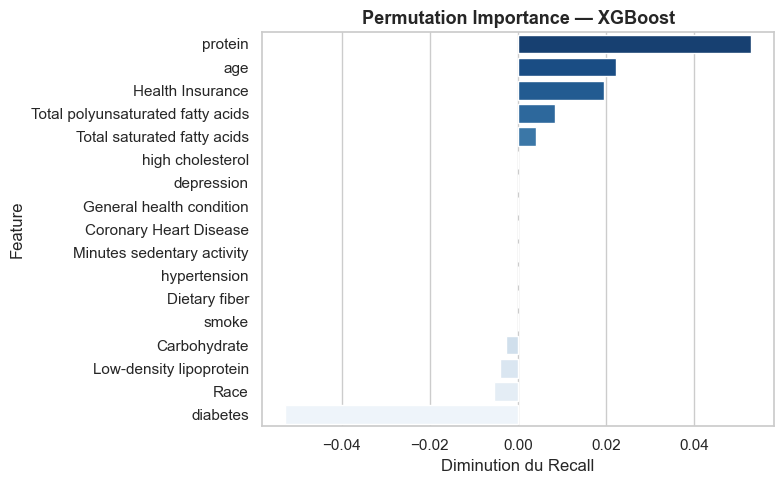

In [17]:
# Permutation Importance — meilleur modèle
best_name  = results_df['Recall'].idxmax()
best_model = best_models_final[best_name]

print(f'Meilleur modèle : {best_name}')
print(f'  Recall  : {results_df.loc[best_name, "Recall"]:.4f}')
print(f'  AUC-ROC : {results_df.loc[best_name, "AUC-ROC"]:.4f}')

result = permutation_importance(
    best_model, X_test, y_test,
    scoring      = 'recall',
    n_repeats    = 10,
    random_state = RANDOM_STATE,
    n_jobs       = -1
)

perm_df = pd.DataFrame({
    'Feature'   : SELECTED_FEATURES,
    'Importance': result.importances_mean
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('\n=== Permutation Importance ===')
print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=perm_df, x='Importance', y='Feature', palette='Blues_r', ax=ax)
ax.set_title(f'Permutation Importance — {best_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Diminution du Recall')
plt.tight_layout()
plt.show()


## 11. Conclusion — Performance et Applicabilité

In [18]:
print('=== Conclusion V3 ===')
print()
print('Progression recall sur les 3 versions :')
print('  V1 — baseline brute          : recall ≈ 0%')
print('  V2 — Feature Selection       : recall ≈ 0-1.4%')
print('  V3 — SMOTE + Tuning          : voir résultats ci-dessous')
print()
print(f'Meilleur modèle V3 : {best_name}')
for metric in results_final_df.columns:
    print(f'  {metric:<12}: {results_final_df.loc[best_name, metric]}')

=== Conclusion V3 ===

Progression recall sur les 3 versions :
  V1 — baseline brute          : recall ≈ 0%
  V2 — Feature Selection       : recall ≈ 0-1.4%
  V3 — SMOTE + Tuning          : voir résultats ci-dessous

Meilleur modèle V3 : XGBoost
  Seuil       : 0.55
  Accuracy    : 0.7372
  Precision   : 0.1028
  Recall      : 0.3056
  F1          : 0.1538
  AUC-ROC     : 0.5355


## 12. Sauvegarde — `pipeline.pkl` + `features.pkl`

In [19]:
with open('pipeline_v3.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('features_v3.pkl', 'wb') as f:
    pickle.dump(SELECTED_FEATURES, f)

print('Artefacts sauvegardés :')
print(f'  pipeline_v3.pkl — {best_name}')
print(f'  features_v3.pkl — {len(SELECTED_FEATURES)} features sélectionnées')

Artefacts sauvegardés :
  pipeline_v3.pkl — XGBoost
  features_v3.pkl — 17 features sélectionnées
